# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g0 = 9.81
shaft_depth = 4000
t_ff = np.sqrt(2 * shaft_depth/g0)

In [2]:
def mine_ode(t, Y, g=g0, alpha=0.0, gammma=2.0):
    """
    Y[0] = y = height above bottom of shaft (m)
    Y[1] = v = velocity (m/s)
    """
    y, v = Y
    dydt = v
    dvdt = -g 
    return [dydt, dvdt]

def hit_bottom(t, Y):
    return Y[0]

hit_bottom.terminal = True
hit_bottom.direction = -1

Y0 = [shaft_depth, 0.0]
sol = solve_ivp(mine_ode, (0,60), Y0, events=hit_bottom, dense_output=True, max_step=0.05)
t = sol.t 
y = sol.y[0]
v = sol.y[1]

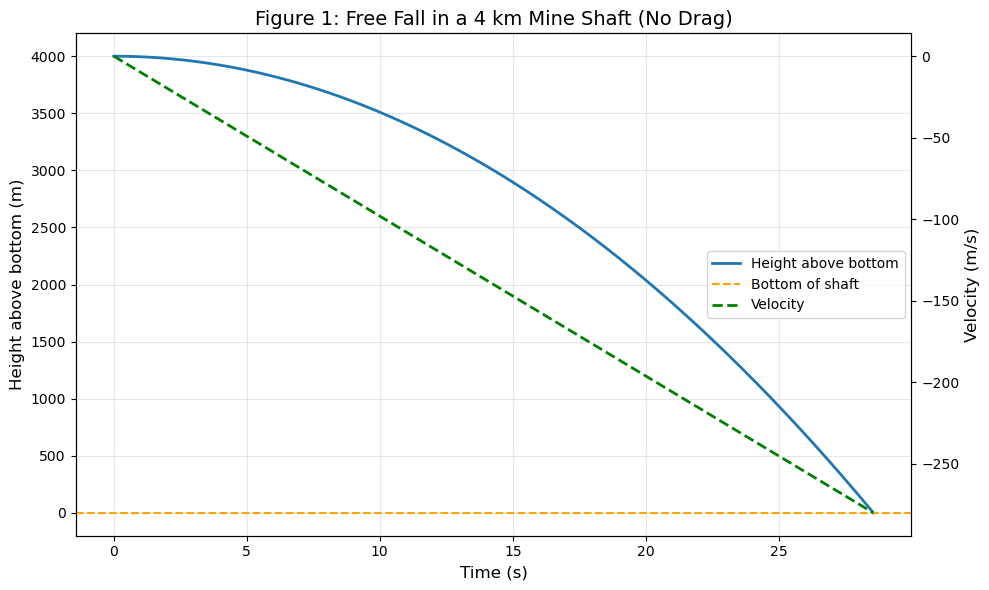

Free-fall time: 28.5569 s
Analytic impact time: 28.556862 s
Numerical impact time: 28.556862 s
Difference: 6.039613e-14 s


In [3]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(t, y, linewidth=2, label='Height above bottom')
ax1.axhline(0, color='orange', linestyle='--', linewidth=1.5, label='Bottom of shaft')
ax1.set_xlabel('Time (s)', fontsize = 12)
ax1.set_ylabel('Height above bottom (m)', fontsize=12)
ax1.set_title('Figure 1: Free Fall in a 4 km Mine Shaft (No Drag)', fontsize=14)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t, v, color='green', linestyle='--', linewidth=2, label='Velocity')
ax2.set_ylabel('Velocity (m/s)', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()

t_event = sol.t_events[0][0]
print(f"Free-fall time: {t_ff:.4f} s")
print(f"Analytic impact time: {t_ff:.6f} s")
print(f"Numerical impact time: {t_event:.6f} s")
print(f"Difference: {abs(t_ff - t_event):.6e} s")

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Part 1 fall time = 14.278 s


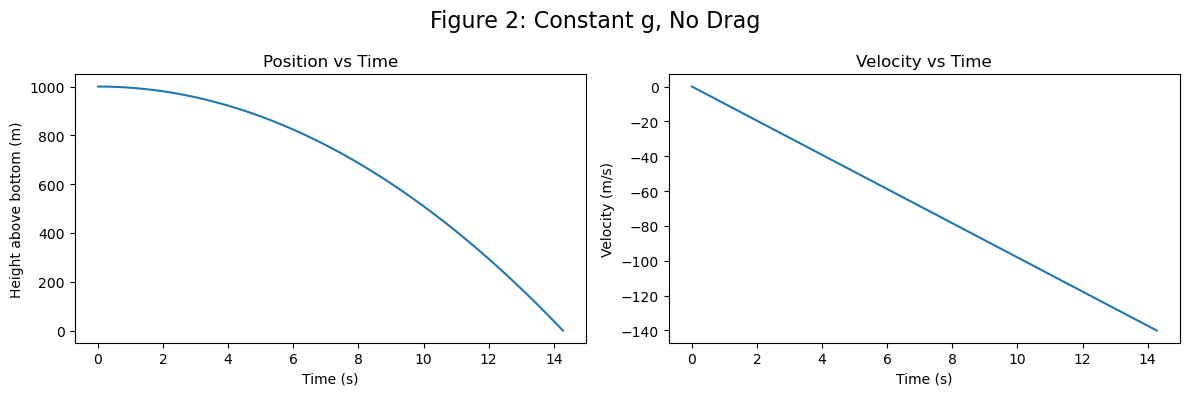

Question 2 fall time = 14.279 s


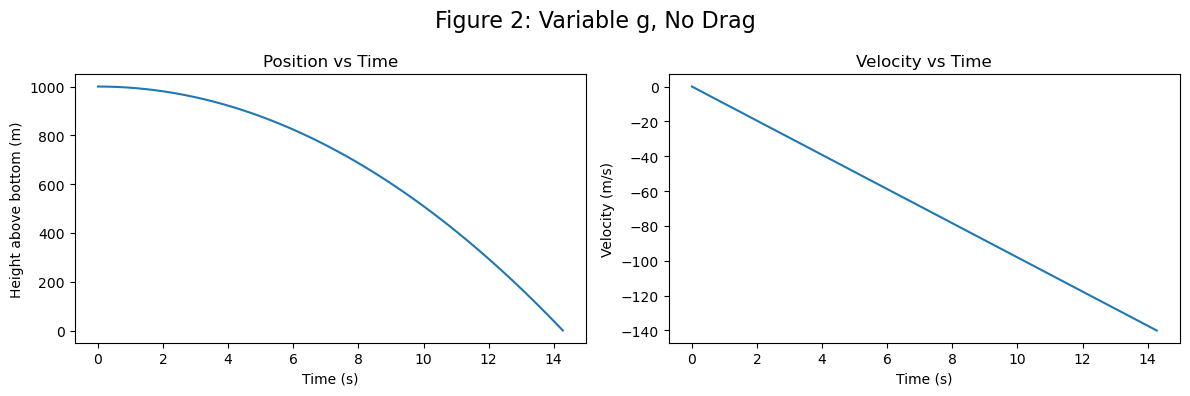

Question 3 fall time = 23.533 s


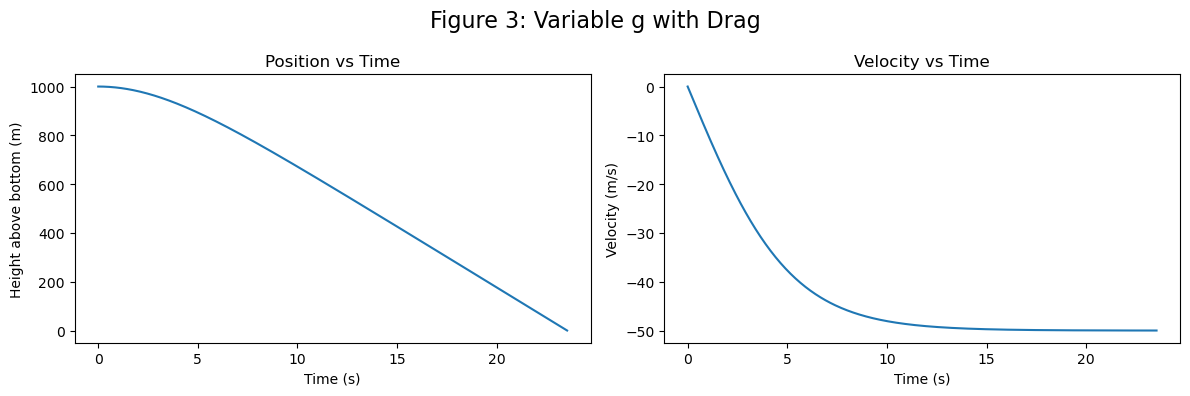

In [4]:
g0 = 9.81
R_earth = 6_378_100
shaft_depth = 1000.0
Y0 = [shaft_depth, 0.0]
def hit_bottom(t, Y):
    return Y[0]

hit_bottom.terminal = True
hit_bottom.direction = -1
def mine_ode_question1(t, Y):
    """
    Y[0] = y = height above bottom of shaft (m)
    Y[1] = v = velocity (m/s)
    """
    y, v = Y
    dydt = v
    dvdt = -g0
    return [dydt, dvdt]

sol1 = solve_ivp(
    mine_ode_question1,
    (0, 60),
    Y0,
    events=hit_bottom,
    dense_output=True,
    max_step=0.05
)
t1 = sol1.t
y1 = sol1.y[0]
v1 = sol1.y[1]
print(f"Part 1 fall time = {sol1.t_events[0][0]:.3f} s")
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(t1, y1)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Height above bottom (m)")
ax[0].set_title("Position vs Time")
ax[1].plot(t1, v1)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Velocity (m/s)")
ax[1].set_title("Velocity vs Time")
fig.suptitle("Figure 2: Constant g, No Drag", fontsize=16)
plt.tight_layout()
plt.show()

## Question 2 
def mine_ode_question2(t, Y):
    """
    Variable gravity: g(r) = g0 * (r/R_earth)
    """
    y, v = Y
    r = R_earth - shaft_depth + y
    g = g0 * (r / R_earth)
    dydt = v
    dvdt = -g
    return [dydt, dvdt]
sol2 = solve_ivp(
    mine_ode_question2,
    (0, 60),
    Y0,
    events=hit_bottom,
    dense_output=True,
    max_step=0.05
)

t2 = sol2.t
y2 = sol2.y[0]
v2 = sol2.y[1]
print(f"Question 2 fall time = {sol2.t_events[0][0]:.3f} s")
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(t2, y2)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Height above bottom (m)")
ax[0].set_title("Position vs Time")
ax[1].plot(t2, v2)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Velocity (m/s)")
ax[1].set_title("Velocity vs Time")
fig.suptitle("Figure 2: Variable g, No Drag", fontsize=16)
plt.tight_layout()
plt.show()

##Question 3
gamma = 2.0
vt = 50.0
beta = g0 / vt**2  
def mine_ode_question3(t, Y):
    """
    Y[0] = y = height above bottom of shaft (m)
    Y[1] = v = velocity (m/s)
    Variable gravity + quadratic drag
    """
    y, v = Y
    r = R_earth - shaft_depth + y
    g = g0 * (r / R_earth)
    dydt = v
    dvdt = -g - beta * v * abs(v)
    return [dydt, dvdt]
sol3 = solve_ivp(
    mine_ode_question3,
    (0, 200),
    Y0,
    events=hit_bottom,
    dense_output=True,
    max_step=0.05
)
t3 = sol3.t
y3 = sol3.y[0]
v3 = sol3.y[1]
print(f"Question 3 fall time = {sol3.t_events[0][0]:.3f} s")
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(t3, y3)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Height above bottom (m)")
ax[0].set_title("Position vs Time")
ax[1].plot(t3, v3)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Velocity (m/s)")
ax[1].set_title("Velocity vs Time")
fig.suptitle("Figure 3: Variable g with Drag", fontsize=16)
plt.tight_layout()
plt.show()

When a height-dependent g is included it makes the fall take slightly longer. As the object falls, it gets closer to the Earth's center, so the gravitational acceleration becomes a little smaller. This ultimately means the object starts to speed up a little more slowly than it would if gravity stayed constant. And since the downward acceleration is a little bit weaker, the object takes a little longer to reach the bottom of the shaft.

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




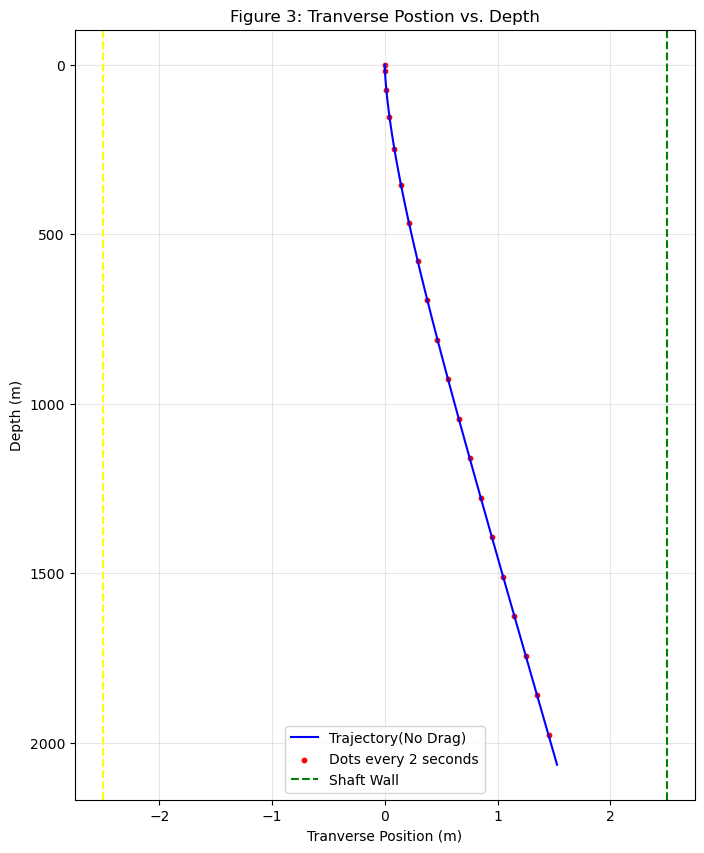

Final Depth: 2065.26m
Final Eastward Drift: 1.5283m
RESULT: REACHED THE BOTTOM

Final Depth: 7653.01m
Final Eastward Drift: 14.6955m
Result: HIT THE WALL



In [5]:
g = 9.81
Omega = 7.292e-5
m = 1.0
depth_limit = 4000
shaft_width = 5.0 
rho = 1.225
C_d = 0.47
A = 0.01

def system(t, state, use_drag=False):
    x, y, vx, vy = state
    ax = 2 * Omega * vy
    ay = g - 2 * Omega * vx
    ax_coriolis = 2 * Omega * vy
    ay_coriolis = -2 * Omega * vx

    ax_drag, ay_drag = 0, 0
    if use_drag:
        v_mag = np.sqrt(vx**2 + vy**2)
        f_drag = 0.5 * rho * v_mag**2 * C_d * A
        ax_drag = -(f_drag * (vx/v_mag)) / m if v_mag > 0 else 0
        ay_drag = -(f_drag * (vy/v_mag)) / m if v_mag > 0 else 0

    ax = ax_coriolis + ax_drag 
    ay = g + ay_coriolis + ay_drag
    return [vx, vy, ax, ay]
t_span = (0,40)
y0 = [0,0,0,0]

sol_no_drag = solve_ivp(system, t_span, y0, args=(True,), 
                        events=lambda t, s, drag:depth_limit - s[1], 
                        t_eval=np.arange(0,40,0.5))

sol_drag = solve_ivp(system, t_span, y0, args=(False,), events=lambda t, s, 
                     drag:depth_limit - s[1], t_eval=np.arange(0,40,0.5))
plt.figure(figsize=(8,10))
plt.plot(sol_no_drag.y[0], sol_no_drag.y[1], 'b-', label='Trajectory(No Drag)')
plt.scatter(sol_no_drag.y[0][::4], sol_no_drag.y[1][::4], color='red', s=10, label='Dots every 2 seconds')

plt.axvline(x=shaft_width/2, color='green', linestyle='--', label='Shaft Wall')
plt.axvline(x=-shaft_width/2, color='yellow', linestyle='--')
plt.gca().invert_yaxis()
plt.title("Figure 3: Tranverse Postion vs. Depth")
plt.xlabel("Tranverse Position (m)")
plt.ylabel("Depth (m)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

def check_collision(sol, label):
    final_x = sol.y[0][-1]
    final_y = sol.y[1][-1]
    print(f"Final Depth: {final_y:.2f}m")
    print(f"Final Eastward Drift: {final_x:.4f}m")
    if abs(final_x) > (shaft_width/2):
        print("Result: HIT THE WALL\n")
    else:
        print("RESULT: REACHED THE BOTTOM\n")

check_collision(sol_no_drag, "Vacuum Calculation")
check_collision(sol_drag, "Air Drag Calculation")

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





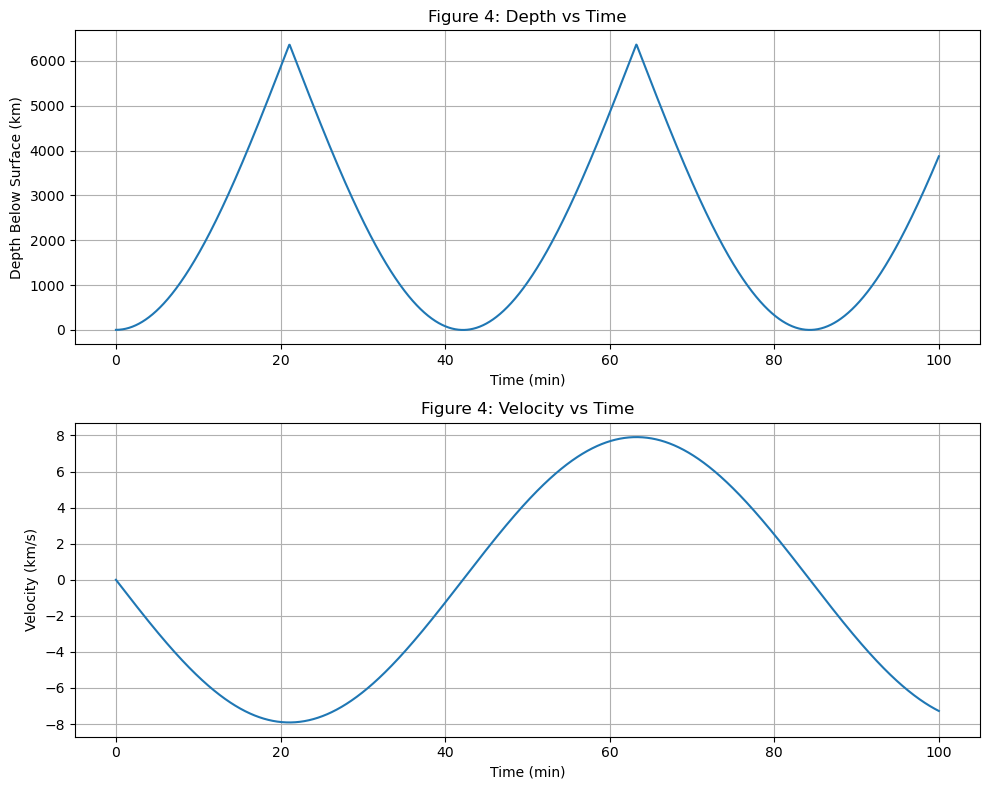

Part 2
-----------------------
Time to center of Earth: 21.09 minutes
Time to reach other side: 42.18 minutes
Part 3
-----------------------
Orbital period near Earth surface : 84.35 minutes
Tunnel oscillation period: 84.35 minutes

The periods are pretty much identical.


In [6]:
G = 6.674e-11
M = 5.972e24
R = 6.371e6
def system(t, y):
    r = y[0]
    v = y[1]
    a = -(G*M / R**3) * r
    return [v, a]

r0 = R
v0 = 0
y0 = [r0, v0]
t_span = (0, 6000)
t_eval = np.linspace(0, 6000, 2000)
sol = solve_ivp(system, t_span, y0, t_eval=t_eval)
depth = R - np.abs(sol.y[0])

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(sol.t/60, depth/1000)
plt.xlabel("Time (min)")
plt.ylabel("Depth Below Surface (km)")
plt.title("Figure 4: Depth vs Time")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(sol.t/60, sol.y[1]/1000)
plt.xlabel("Time (min)")
plt.ylabel("Velocity (km/s)")
plt.title("Figure 4: Velocity vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()


omega = np.sqrt(G * M / R**3)

T = 2 * np.pi / omega 
t_center = T / 4
t_other_side = T / 2
v_max = np.sqrt(G*M / R)
print("Part 2")
print("-----------------------")
print(f"Time to center of Earth: {t_center/60:.2f} minutes")
print(f"Time to reach other side: {t_other_side/60:.2f} minutes")

v_orbit = np.sqrt(G * M / R)
T_orbit = (2 * np.pi * R) / v_orbit

print("Part 3")
print("-----------------------")
print(f"Orbital period near Earth surface : {T_orbit/60:.2f} minutes")
print(f"Tunnel oscillation period: {T/60:.2f} minutes")
print()
if abs(T_orbit - T) < 1:
    print("The periods are pretty much identical.")


## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

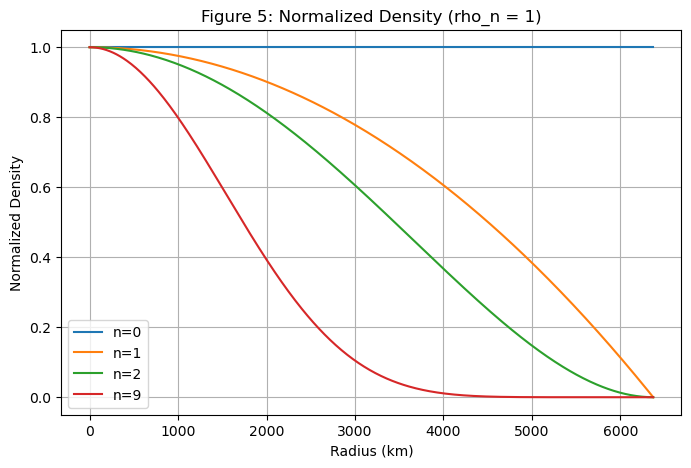

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

M_earth = 5.972e24
R_earth = 6.371e6
n_values = [0, 1, 2, 9]

def get_rho_n(n):
    integrand = lambda r: 4 * np.pi * r**2 * (1-(r/R)**2)**n
    total_integral, _ = quad(integrand, 0, R_earth)
    return M_earth / total_integral

radii = np.linspace(0, R_earth, 500)
plt.figure(figsize=(8,5))

for n in n_values:
    density = (1 - (radii/R_earth) ** 2) ** n
    plt.plot(radii/1000, density, label=f'n={n}')

plt.title("Figure 5: Normalized Density (rho_n = 1)")
plt.xlabel("Radius (km)")
plt.ylabel("Normalized Density")
plt.legend()
plt.grid(True)
plt.show()

### Part 5, Section B (Forces)

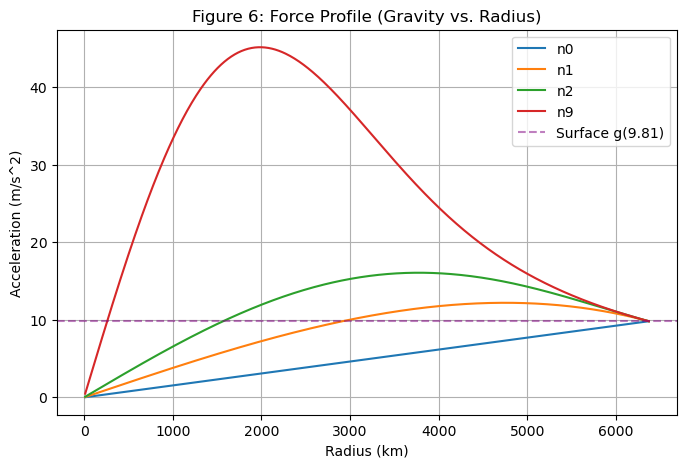

In [8]:
G = 6.6743e-11
def get_gravity(r, n, rho_n):
    if r == 0: return 0
    integrand = lambda x: 4 * np.pi * x**2 * (rho_n * (1 - (x/R_earth)**2)**n)
    m_enclosed, _ = quad(integrand, 0, r)
    return G * m_enclosed / r**2

plt.figure(figsize=(8,5))
for n in n_values:
    rho_n = get_rho_n(n)
    g_profile = [get_gravity(r, n, rho_n) for r in radii[1:]]
    plt.plot(radii[1:]/1000, g_profile, label=f'n{n}')

plt.axhline(9.81, color='purple', linestyle='--', alpha=0.5, label='Surface g(9.81)')
plt.title("Figure 6: Force Profile (Gravity vs. Radius)")
plt.xlabel("Radius (km)")
plt.ylabel("Acceleration (m/s^2)")
plt.legend()
plt.grid(True)
plt.show()

### Part 5, Section C (Equations of Motion)

n     | Time to Center (s)   | Max Speed (m/s)     
--------------------------------------------------
 0    | 1265.23              | 7909.67             
 1    | 1094.68              | 10463.52            
 2    | 1033.35              | 12189.68            
 9    | 942.20               | 18380.94            


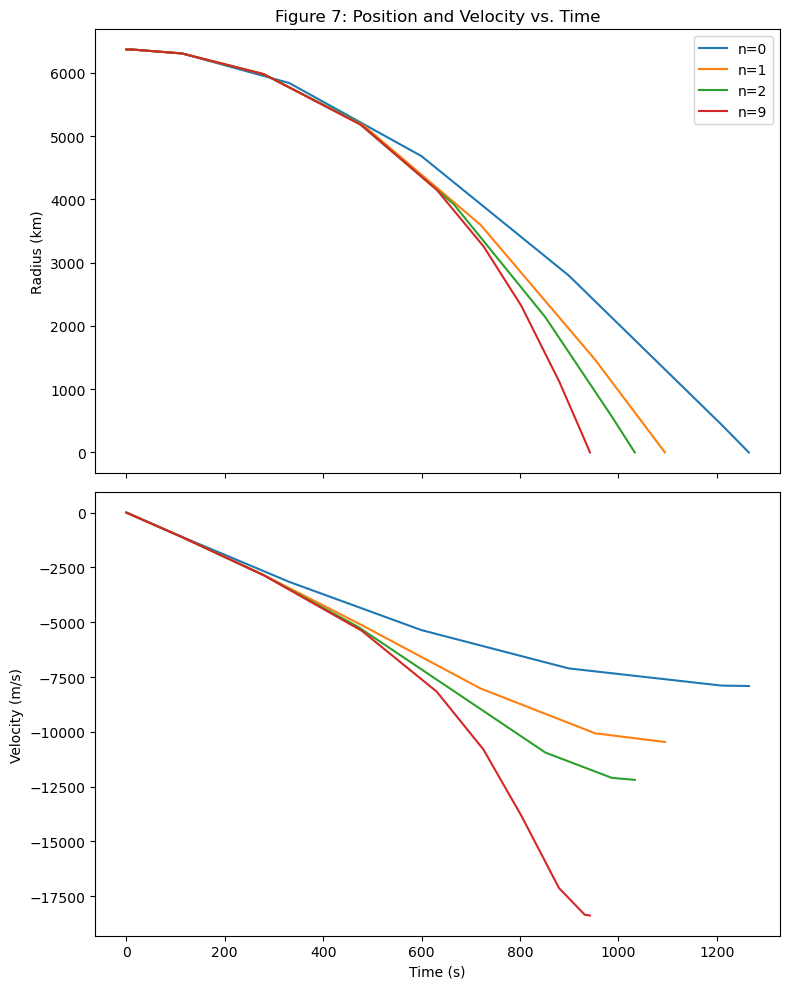

In [9]:
from scipy.integrate import solve_ivp

def motion_ode(t, state, n, rho_n):
    r, v = state
    g_val = get_gravity(r, n, rho_n)
    return [v, -g_val]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,10), sharex=True)
print(f"{'n':<5} | {'Time to Center (s)':<20} | {'Max Speed (m/s)':<20}")
print("-" * 50)

for n in n_values:
    rho_n = get_rho_n(n)
    reach_center = lambda t, s, n, rho_n: s[0]
    reach_center.terminal = True
    sol = solve_ivp(motion_ode, [0, 5000], 
                    [R_earth, 0], args=(n, rho_n), events=reach_center, rtol=1e-5)
    ax1. plot(sol.t, sol.y[0]/1000, label=f'n={n}')
    ax2.plot(sol.t, sol.y[1], label=f'n={n}')
    print(f"{n:< 5} | {sol.t[-1]:<20.2f} | {abs(sol.y[1][-1]):<20.2f}")

ax1.set_title("Figure 7: Position and Velocity vs. Time")
ax1.set_ylabel("Radius (km)")
ax2.set_ylabel("Velocity (m/s)")
ax2.set_xlabel("Time (s)")
ax1.legend()
plt.tight_layout()
plt.show()

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [10]:
M_moon = 7.347e22
R_moon = 1.737e6
def get_avg_density(M, R):
    volume = (4/3) * np.pi * R**3
    return M / volume

rho_earth = get_avg_density(M_earth, R_earth)
rho_moon = get_avg_density(M_moon, R_moon)

def time_to_center(M,R):
    return (np.pi / 2) * np.sqrt(R**3 / (G*M))

t_earth = time_to_center(M_earth, R_earth)
t_moon = time_to_center(M_moon, R_moon)

print(f"DENSITY COMPARISON:")
print(f"Earth Average Density: {rho_earth:.2f} kg/m^3")
print(f"Moon Average Density: {rho_moon:.2f} kg/m^3")
print(f"The Moon is {rho_moon/rho_earth:.2%} as dense as the Earth. \n")
print(f"---------------------")
print(f"TRAVEL TIME TO CENTER (POLE-TO-POLE):")
print(f"Travel time (Earth): {t_earth/60:.2f} minutes")
print(f"Travel time (Moon): {t_moon/60:.2f} minutes")

DENSITY COMPARISON:
Earth Average Density: 5513.26 kg/m^3
Moon Average Density: 3346.74 kg/m^3
The Moon is 60.70% as dense as the Earth. 

---------------------
TRAVEL TIME TO CENTER (POLE-TO-POLE):
Travel time (Earth): 21.09 minutes
Travel time (Moon): 27.07 minutes


## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

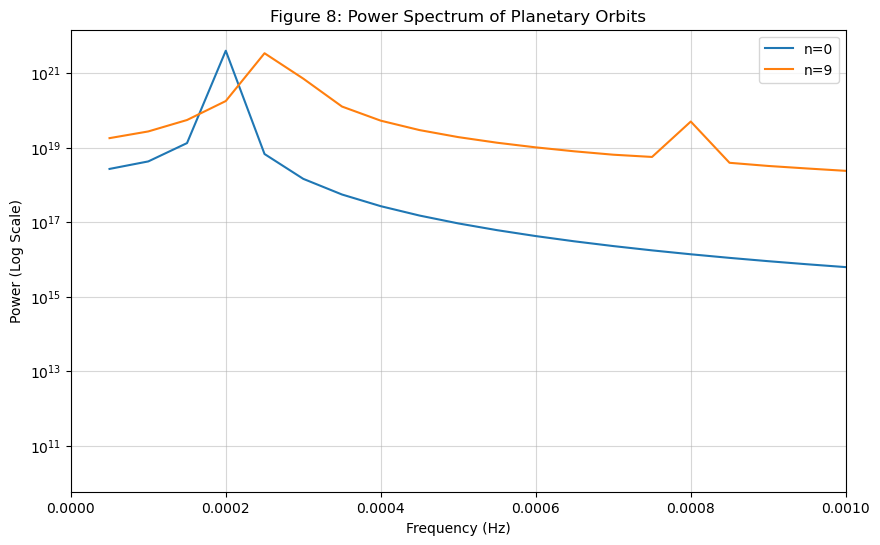

In [12]:
from scipy.fft import fft, fftfreq

n_test = [0,9]
sampling_rate = 1.0
t_long = np.arange(0, 20000, sampling_rate)
spectra_data = {}

for n in n_test:
    rho_n = get_rho_n(n)
    sol = solve_ivp(motion_ode, [t_long[0], t_long[-1]], [R_earth, 0], 
                    args=(n, rho_n), t_eval=t_long, rtol=1e-7)
    y_pos = sol.y[0]
    N = len(y_pos)
    yf = fft(y_pos)
    xf = fftfreq(N, sampling_rate)
    power = np.abs(yf[:N//2])**2
    freqs = xf[:N//2]
    spectra_data[n] = (freqs, power)

plt.figure(figsize=(10,6))
for n in n_test:
    freqs, power = spectra_data[n]
    plt.semilogy(freqs[1:], power[1:], label=f'n={n}')

plt.title("Figure 8: Power Spectrum of Planetary Orbits")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (Log Scale)")
plt.xlim(0, 0.001)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In the plot above we see that the frequency at n = 0 (uniform Earth), is displaying a small peak. That would be the "pure" vibration as the gravity changes. But when n = 9, we see that the main peak goes to a higher frequency, because mass is centered at the core here, thus the orbit is faster. 

Describe what we see here: